# 05 — Decision Tree

Train a decision tree classifier and evaluate it, noting its tendency to overfit on imbalanced data.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

from src.data_preprocessing import load_processed
from src.model_training import train_decision_tree
from src.evaluation import evaluate_model
from src.visualization import plot_confusion_matrix, plot_roc_curves, plot_pr_curves

I0000 00:00:1781683812.384796   18146 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781683812.421667   18146 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781683813.372225   18146 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
X_train, X_test, y_train, y_test = load_processed()

## Train

In [3]:
model = train_decision_tree(X_train, y_train)
print(f'Tree depth: {model.get_depth()} | Leaves: {model.get_n_leaves()}')

Model saved: /home/suman/Documents/intern_project/credit_card_fraud_detection/src/../models/decision_tree.pkl
Tree depth: 10 | Leaves: 97


## Evaluate


Model: decision_tree
ROC-AUC: 0.8915  |  AUPRC: 0.4639
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     56864
       Fraud       0.13      0.79      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.89      0.61     56962
weighted avg       1.00      0.99      0.99     56962

Saved: /home/suman/Documents/intern_project/credit_card_fraud_detection/src/../results/confusion_matrices/decision_tree.png


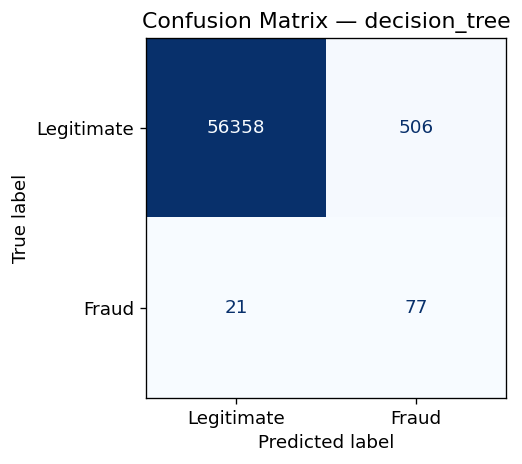

In [4]:
result = evaluate_model(model, X_test, y_test, 'decision_tree')
plot_confusion_matrix(result['confusion_matrix'], 'decision_tree')

## Feature Importance

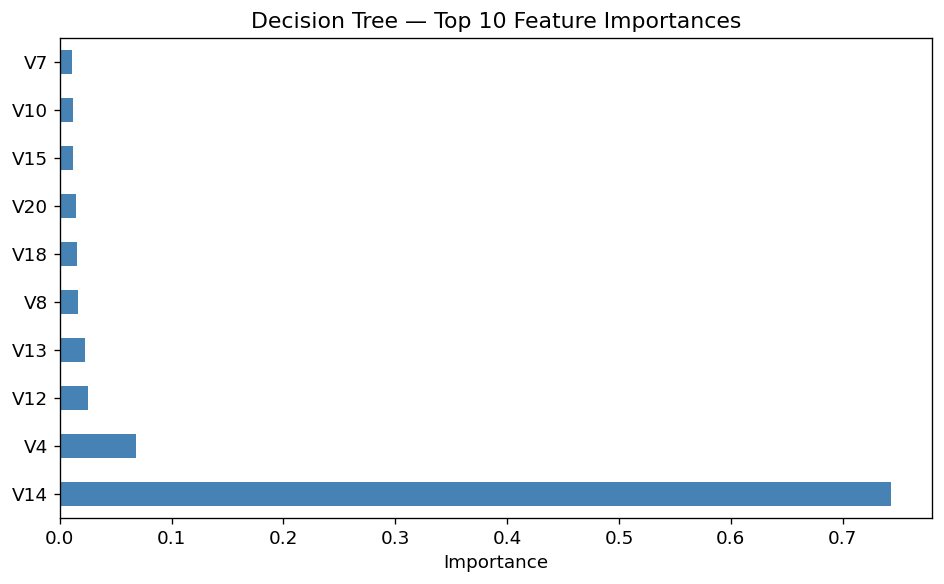

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X_train.columns)
top10 = importances.nlargest(10)

fig, ax = plt.subplots(figsize=(8, 5))
top10.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Decision Tree — Top 10 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

Saved: /home/suman/Documents/intern_project/credit_card_fraud_detection/src/../results/roc_curves/roc_comparison_decision_tree.png


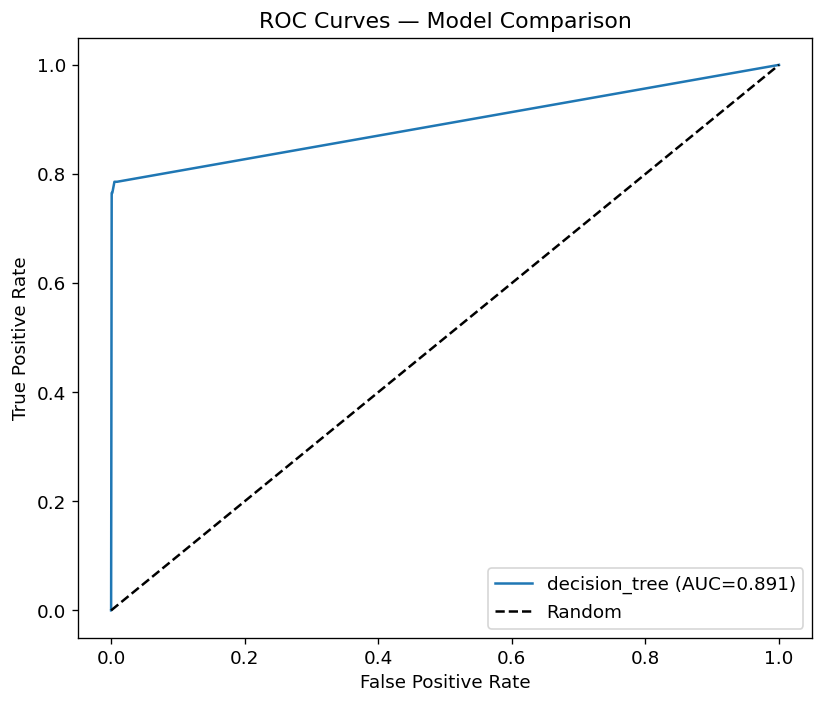

Inside pr curve
Saved: /home/suman/Documents/intern_project/credit_card_fraud_detection/src/../results/pr_curves/auprc_comparison_decision_tree.png


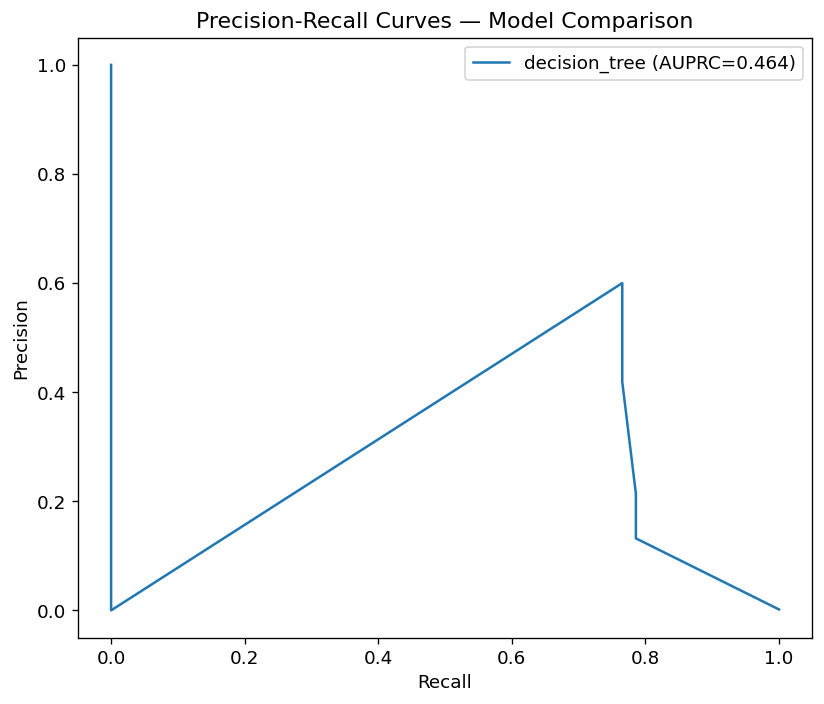

In [6]:
plot_roc_curves([result])
plot_pr_curves([result])